In [1]:
import gym
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import tensorflow_probability as tfp
import warnings
warnings.filterwarnings('ignore')
import math
print(gym.__version__)


0.26.2


In [2]:
#!pip install gym==0.26.2


In [22]:
env = gym.make("CartPole-v0")

#  neural network for the policy
model = keras.Sequential([
    keras.layers.Dense(32, activation='linear', input_shape=(4,)),
    keras.layers.Dense(12, activation='relu', input_shape=(32,)),
    keras.layers.Dense(2, activation='softmax')])  # Two actions: left and right])



# optimizer for training
optimizer = keras.optimizers.Adam(learning_rate=0.005)

#  discount factor
gamma = 0.95
#  gradient clipping
max_grad_norm = 1

#num_episodes = 5000

last_100_episodes =[]
all_episodes = []
episode_rewards = []
for batch in range (0, 2000):
    num_episodes = 20
# Training loop
    obs_history_batch = []
    reward_history_batch = []
    action_history_batch = []
    discounted_rewards_batch = []
    loss = 0
    with tf.GradientTape() as tape:
        #tape.watch(model.trainable_variables)

        for episode in range(num_episodes):
            obs_history_eps = []
            reward_history_eps = []
            action_history_eps = []
            selected_probs_eps = []

            #########new ####################
            prob_output_eps = tf.Variable(tf.zeros([0, 2], dtype=tf.float32))
            index_history_eps = []
            ##############################

            terminated = False
            truncated = False

            while (not terminated) and (not truncated):
                # sampling an action from the policy
                #obs_tensor = tf.convert_to_tensor(np.array([obs_history[-1] if obs_history else env.reset()], dtype=np.float32))
                obs_array = np.array(obs_history_eps[-1] if obs_history_eps else env.reset()[0], dtype=np.float32)
                obs_array = obs_array.reshape((1, 4))  # Reshape to 1D array
                obs_tensor =tf.convert_to_tensor(obs_array)



                prob = model(obs_tensor)
                #print("probability", prob)
                dist = tfp.distributions.Categorical(probs=prob, dtype=tf.float32)
                #print("disribution", dist)
                action = dist.sample()
                #print("selected proba", prob[0][int(action)])

                obs, reward, terminated, truncated, info=  env.step(int(action.numpy()[0]))

                obs_history_eps.append(obs)
                reward_history_eps.append(reward)
                action_history_eps.append(action)
                selected_probs_eps.append(prob[0][int(action)])

                obs_history_batch.append(obs)
                reward_history_batch.append(reward)
                action_history_batch.append(action)

                #print(prob)
                #print(prob[0])
                #####new##########
                index_history_eps.append(int(action))
                prob_output_eps = tf.concat([prob_output_eps, prob], axis=0)
                ################

            print(f"CartPole-v0, episode {episode + batch*20}, score {sum(reward_history_eps)}")
            episode_rewards.append(sum(reward_history_eps))

            if len(episode_rewards) >= 100:
              avg_reward = np.mean(episode_rewards[-100:])
              last_100_episodes.append(avg_reward )
              print(f"Average Reward (Last 100 Episodes): {avg_reward}")


            #  discounted rewards
            discounted_rewards_eps = []
            reward_sum = 0
            for r in reward_history_eps[::-1]:
                reward_sum = r + gamma * reward_sum
                discounted_rewards_eps.insert(0, reward_sum)
            #print(discounted_rewards)

            discounted_rewards_eps = np.array(discounted_rewards_eps)
            discounted_rewards_eps -= np.mean(discounted_rewards_eps)
            discounted_rewards_eps /= np.std(discounted_rewards_eps)

        # Compute loss and perform a gradient update

                #loss =0
                #action_prob = model(np.array(obs_history)) #get output of probability actions
                #print(action_prob)
                #action_mask = tf.one_hot(action_history, depth=2) # select probability of the chosen action
                #selected_action_probs = tf.reduce_mean(action_prob * action_mask, axis=1)
                #print(type(selected_action_probs))
                #print(type(discounted_rewards))
            reshaped_discounted_rewards = discounted_rewards_eps.reshape(-1, 1)
            #epsilon = 1e-8
            #log_probs = tf.math.log(selected_action_probs + epsilon)
            #print(log_probs)
            tensor_logprob = tf.math.log(tf.convert_to_tensor(selected_probs_eps, dtype=tf.float32))
            tensor_rewards = tf.convert_to_tensor(reshaped_discounted_rewards, dtype=tf.float32)


            #############updated loss #######################
            index_history_eps = tf.convert_to_tensor(index_history_eps, dtype=tf.int32)  # Or tf.int64, depending on your needs

            #selected_values = tf.math.log(tf.gather(prob_output_eps, index_history_eps, axis=1))

            #tensor_logprob = tf.math.log(tf.convert_to_tensor(selected_probs_eps, dtype=tf.float32))
            tensor_rewards = tf.convert_to_tensor(reshaped_discounted_rewards, dtype=tf.float32)
            ###normalize the discounted rewards
            mean = tf.reduce_mean(tensor_rewards)
            std = tf.math.reduce_std(tensor_rewards)

            # Normalize the discounted rewards
            normalized_rewards = (tensor_rewards - mean) / (std + 1e-8)
            tensor_rewards_normalized = tf.convert_to_tensor(normalized_rewards, dtype=tf.float32)

            #loss =loss +  tf.reduce_sum (index_history_eps * tensor_rewards_normalized)
            for idx in range (0, tensor_rewards_normalized.shape[0]):
                loss = loss + tensor_rewards_normalized[idx] * tf.math.log(prob_output_eps[idx][int(index_history_eps[idx])])


            #########################

            #loss = loss + tf.reduce_sum (tensor_logprob * tensor_rewards)
            #print(loss)
            #print(loss)
        #print(loss)
        #loss = -loss
        loss = -tf.convert_to_tensor(loss)
    grads = tape.gradient(loss, model.trainable_variables)
    #print("GRADIENT", grads)
#print(grads)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))



# Plot the rewards
'''
plt.plot(episode_rewards)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Rewards vs. Episodes')
plt.show()
'''
#print(len(episode_rewards))
episode_numbers = list(range(1, len(episode_rewards) + 1))
#print(len(episode_numbers))
plt.plot(episode_numbers, episode_rewards, label="Episode Reward")


moving_avg = np.convolve(episode_rewards, np.ones(100) / 100, mode='valid')
plt.plot(episode_numbers[-len(moving_avg):], moving_avg, label="Moving Average (100 episodes)")

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.show()

# Close the environment
env.close()


Streaming output truncated to the last 5000 lines.
CartPole-v0, episode 1955, score 200.0
Average Reward (Last 100 Episodes): 200.0
CartPole-v0, episode 1956, score 200.0
Average Reward (Last 100 Episodes): 200.0
CartPole-v0, episode 1957, score 200.0
Average Reward (Last 100 Episodes): 200.0
CartPole-v0, episode 1958, score 200.0
Average Reward (Last 100 Episodes): 200.0
CartPole-v0, episode 1959, score 200.0
Average Reward (Last 100 Episodes): 200.0
CartPole-v0, episode 1960, score 200.0
Average Reward (Last 100 Episodes): 200.0
CartPole-v0, episode 1961, score 200.0
Average Reward (Last 100 Episodes): 200.0
CartPole-v0, episode 1962, score 200.0
Average Reward (Last 100 Episodes): 200.0
CartPole-v0, episode 1963, score 200.0
Average Reward (Last 100 Episodes): 200.0
CartPole-v0, episode 1964, score 200.0
Average Reward (Last 100 Episodes): 200.0
CartPole-v0, episode 1965, score 200.0
Average Reward (Last 100 Episodes): 200.0
CartPole-v0, episode 1966, score 200.0
Average Reward (Las

KeyboardInterrupt: ignored

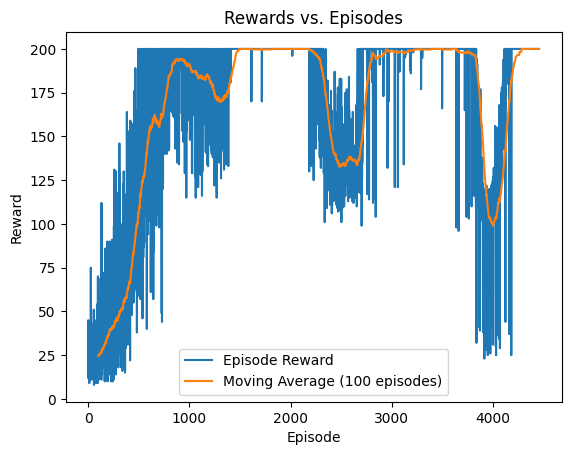

In [23]:

#print(len(episode_rewards))
episode_numbers = list(range(1, len(episode_rewards) + 1))
#print(len(episode_numbers))
plt.plot(episode_numbers, episode_rewards, label="Episode Reward")


moving_avg = np.convolve(episode_rewards, np.ones(100) / 100, mode='valid')
plt.plot(episode_numbers[-len(moving_avg):], moving_avg, label="Moving Average (100 episodes)")
plt.title('Rewards vs. Episodes')

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.show()
